## Detectores Matemáticos Clássicos e Suas Limitações
### Cantos de Harris

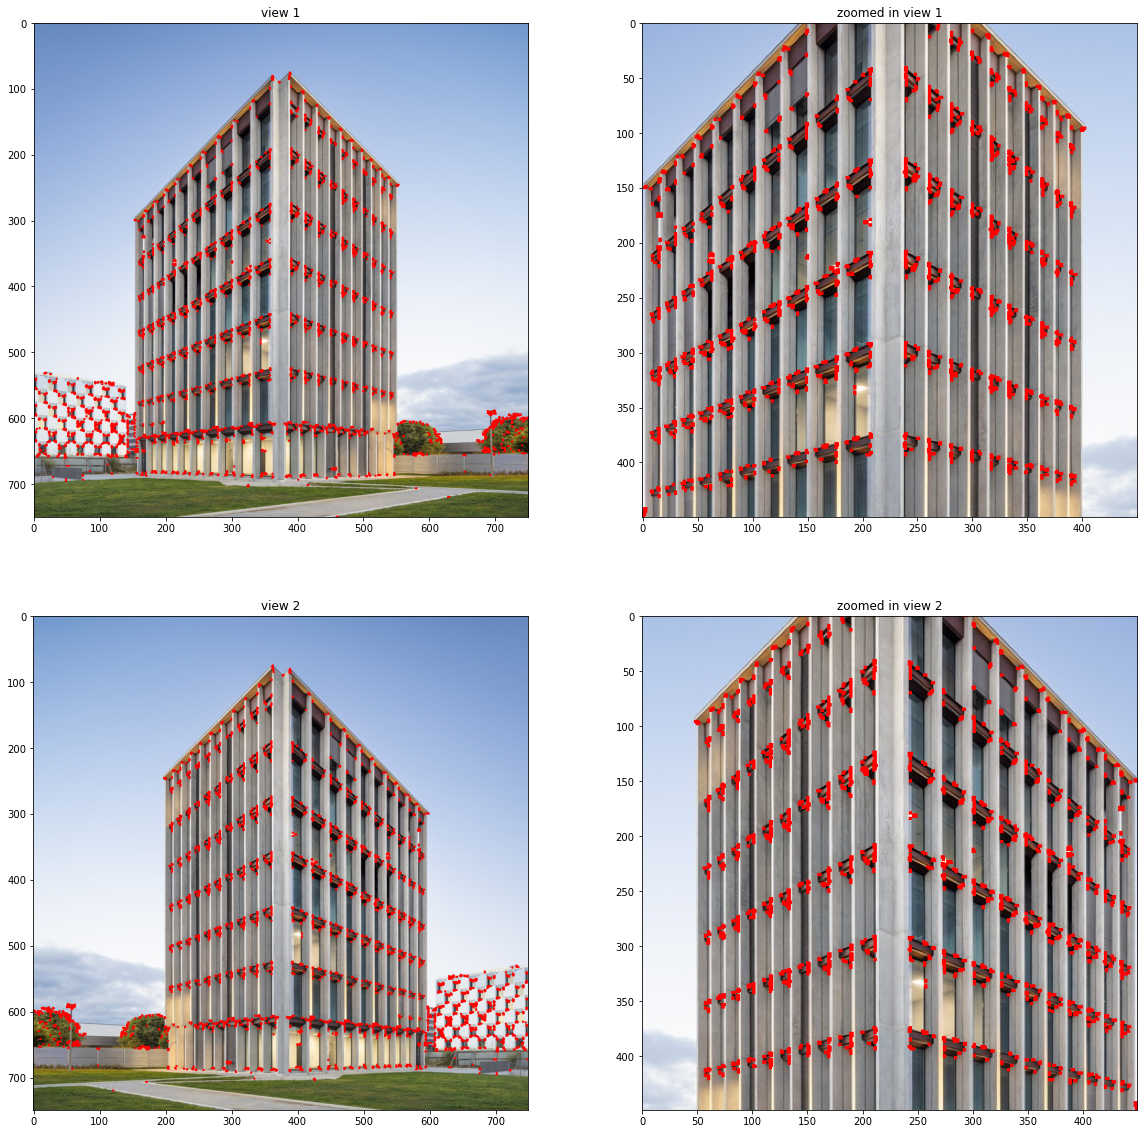

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def harris_corner(img, blockSize=2, ksize=3, k=0.04, threshold=0.01):
    image = cv2.imread(img)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    harris = cv2.cornerHarris(gray, blockSize, ksize, k)
    harris = cv2.dilate(harris, None)
    image[harris > threshold * harris.max()] = [0, 0, 255]
    return image

def coords(img, zoom_factor=0.6):
    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    
    top_left = ((w - new_w) // 2, (h - new_h) // 2)
    bottom_right = (top_left[0] + new_w, top_left[1] + new_h)
    return top_left, bottom_right

def zoom(img, top_left, bottom_right):
    return img[top_left[1]:bottom_right[1], top_left[0]:bottom_right[0]]

image_paths = ['building.jpg', 'building2.jpg']
images_with_corners = [harris_corner(aux) for aux in image_paths]

zoom_factor = 0.6
zoom_images = [zoom(aux1, *coords(aux1, zoom_factor)) for aux1 in images_with_corners]

plt.figure(figsize=(20, 20))

for i, (image, x) in enumerate(zip(images_with_corners, zoom_images)):
    plt.subplot(2, 2, 2 * i + 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f'view {i + 1}')
    plt.axis('on')
    
    plt.subplot(2, 2, 2 * i + 2)
    plt.imshow(cv2.cvtColor(x, cv2.COLOR_BGR2RGB))
    plt.title(f'zoomed in view {i + 1}')
    plt.axis('on')

plt.show()

## Detetores Mais Recentes (Invariantes à Escala)
### SIFT (Scale-Invariant Feature Transform)
### Scale-Space Concepts

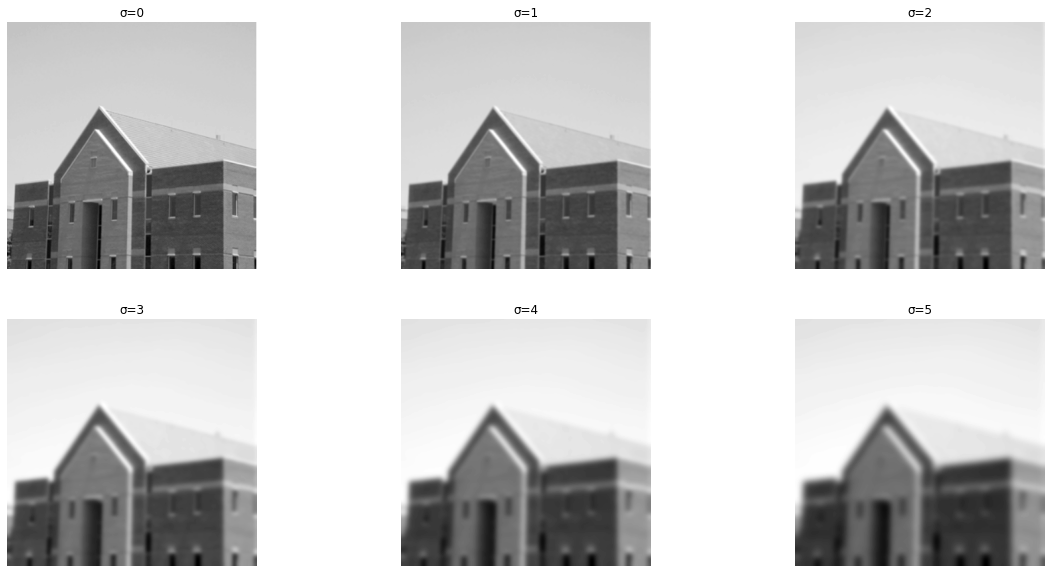

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('sift.png', cv2.IMREAD_GRAYSCALE)

blurred_images = [image]
for i in range(1, 6):
    blurred_images.append(cv2.GaussianBlur(image, (0, 0), sigmaX=i, sigmaY=i))

plt.figure(figsize=(20, 10))
for i, img in enumerate(blurred_images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'σ={i}')
    plt.axis('off')
plt.show()

### Detecção usando SIFT

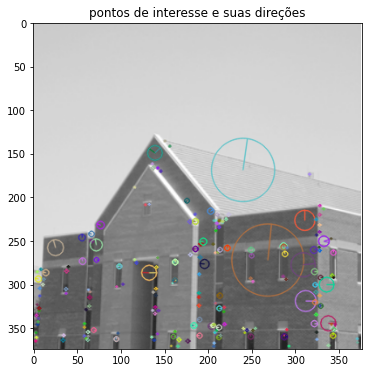

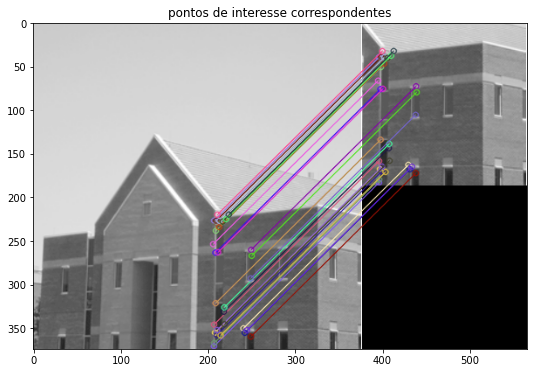

In [68]:
def detect_keypoints(image):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

def draw_keypoints_with_directions(image, keypoints):
    image_with_directions = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    return image_with_directions

def find_and_draw_matches(img1, kp1, des1, img2, kp2, des2):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:36], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return img_matches

matches_building_corner = find_and_draw_matches(building, kp_building, des_building, corner, kp_corner, des_corner)
building = cv2.imread('sift.png', cv2.IMREAD_GRAYSCALE)

height, width = building.shape
corner = building[int(height*0.5):, int(width*0.5):]

kp_building, des_building = detect_keypoints(building)
kp_corner, des_corner = detect_keypoints(corner)

building_with_directions = draw_keypoints_with_directions(building, kp_building)
corner_with_directions = draw_keypoints_with_directions(corner, kp_corner)

plt.figure(figsize=(12, 6))

plt.subplot(1, 1, 1)
plt.imshow(building_with_directions, cmap='gray')
plt.title('pontos de interesse e suas direções')
plt.axis('on')

plt.figure(figsize=(12, 6))
plt.imshow(matches_building_corner, cmap='gray')
plt.title('pontos de interesse correspondentes')
plt.axis('on')

plt.show()

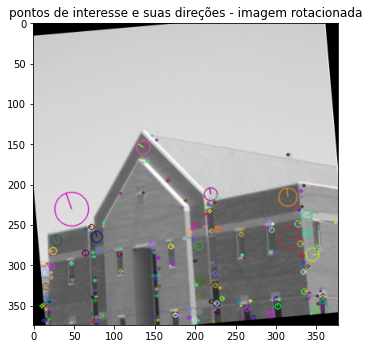

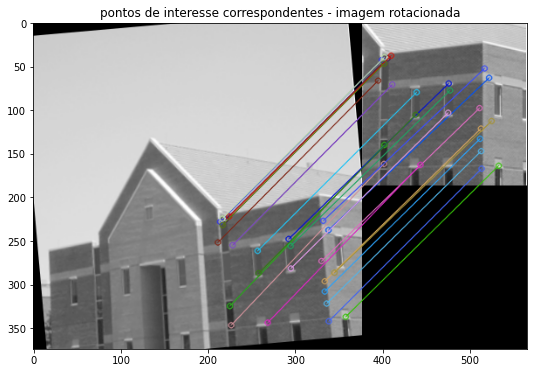

In [67]:
def detect_keypoints(image):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

def draw_keypoints_with_directions(image, keypoints):
    image_with_directions = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    return image_with_directions

def find_and_draw_matches(img1, kp1, des1, img2, kp2, des2):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:26], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return img_matches

building = cv2.imread('sift.png', cv2.IMREAD_GRAYSCALE)

resized_building = cv2.resize(building, (building.shape[1] // 2, building.shape[0] // 2))
matches_rotated_corner = find_and_draw_matches(rotated_building, kp_rotated, des_rotated, corner, kp_corner, des_corner)

height, width = building.shape
center = (width // 2, height // 2)
matrix = cv2.getRotationMatrix2D(center, 5, 1.0)
rotated_building = cv2.warpAffine(building, matrix, (width, height))

corner = building[int(height*0.5):, int(width*0.5):]

kp_rotated, des_rotated = detect_keypoints(rotated_building)
kp_corner, des_corner = detect_keypoints(corner)

rotated_with_directions = draw_keypoints_with_directions(rotated_building, kp_rotated)
corner_with_directions = draw_keypoints_with_directions(corner, kp_corner)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rotated_with_directions, cmap='gray')
plt.title('pontos de interesse e suas direções - imagem rotacionada')
plt.axis('on')

plt.figure(figsize=(12, 6))
plt.imshow(matches_rotated_corner, cmap='gray')
plt.title('pontos de interesse correspondentes - imagem rotacionada')
plt.axis('on')

plt.show()

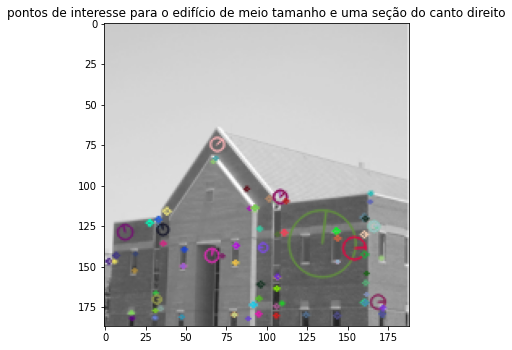

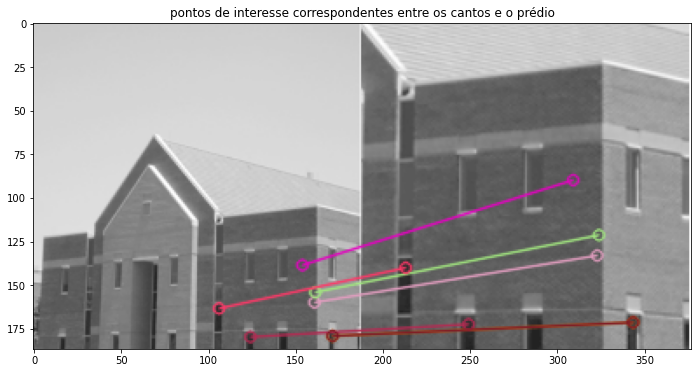

In [66]:
def detect_keypoints(image):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

def draw_keypoints_with_directions(image, keypoints):
    image_with_directions = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    return image_with_directions

def find_and_draw_matches(img1, kp1, des1, img2, kp2, des2):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:7], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return img_matches

building = cv2.imread('sift.png', cv2.IMREAD_GRAYSCALE)
resized_building = cv2.resize(building, (building.shape[1] // 2, building.shape[0] // 2))
corner = building[int(building.shape[0]*0.5):, int(building.shape[1]*0.5):]

kp_resized, des_resized = detect_keypoints(resized_building)
kp_corner, des_corner = detect_keypoints(corner)

resized_with_directions = draw_keypoints_with_directions(resized_building, kp_resized)
corner_with_directions = draw_keypoints_with_directions(corner, kp_corner)

matches_resized_corner = find_and_draw_matches(resized_building, kp_resized, des_resized, corner, kp_corner, des_corner)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(resized_with_directions, cmap='gray')
plt.title('pontos de interesse para o edifício de meio tamanho e uma seção do canto direito')
plt.axis('on')

plt.figure(figsize=(12, 6))
plt.imshow(matches_resized_corner, cmap='gray')
plt.title('pontos de interesse correspondentes entre os cantos e o prédio')
plt.axis('on')
plt.show()

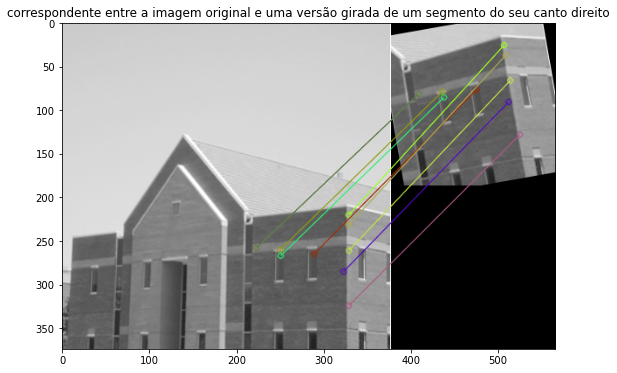

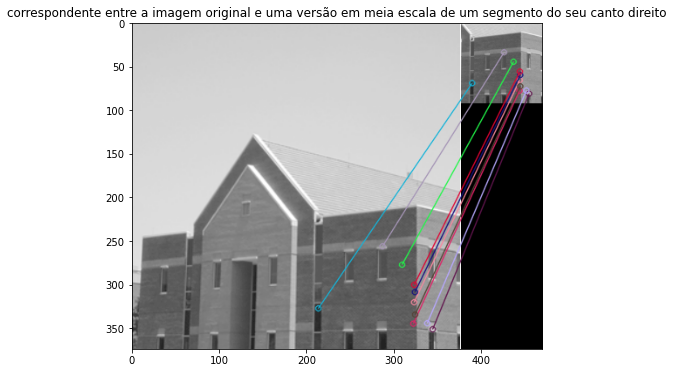

In [65]:
def detect_keypoints(image):
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

def find_and_draw_matches(img1, kp1, des1, img2, kp2, des2, max_matches=10):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:max_matches], None, 
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    return img_matches

building = cv2.imread('sift.png', cv2.IMREAD_GRAYSCALE)
corner = building[int(building.shape[0]*0.5):, int(building.shape[1]*0.5):]
height, width = corner.shape
center = (width // 2, height // 2)
matrix = cv2.getRotationMatrix2D(center, 10, 1.0)
rotated_corner = cv2.warpAffine(corner, matrix, (width, height))

kp_building, des_building = detect_keypoints(building)
kp_rotated_corner, des_rotated_corner = detect_keypoints(rotated_corner)

matches_rotated_corner = find_and_draw_matches(building, kp_building, des_building, rotated_corner, 
                                               kp_rotated_corner, des_rotated_corner, max_matches=10)

corner = building[int(building.shape[0]*0.5):, int(building.shape[1]*0.5):]
resized_corner = cv2.resize(corner, (corner.shape[1] // 2, corner.shape[0] // 2))

kp_building, des_building = detect_keypoints(building)
kp_resized_corner, des_resized_corner = detect_keypoints(resized_corner)

matches_resized_corner = find_and_draw_matches(building, kp_building, des_building, resized_corner, 
                                               kp_resized_corner, des_resized_corner, max_matches=10)

plt.figure(figsize=(12, 6))
plt.imshow(matches_rotated_corner, cmap='gray')
plt.title('correspondente entre a imagem original e uma versão girada de um segmento do seu canto direito')
plt.axis('on')

plt.figure(figsize=(12, 6))
plt.imshow(matches_resized_corner, cmap='gray')
plt.title('correspondente entre a imagem original e uma versão em meia escala de um segmento do seu canto direito')
plt.axis('on')
plt.show()